# Final Brain Tumor Detection Pipeline

**Part A (Sections 1–5b):** Logistic Regression baseline — trained on 253 `boolcancer` images (yes/no).

**Part B (Section 6):** type_cnn_model — classifies tumor type (glioma / meningioma / pituitary).

**Part C (Sections 7–11):** ResNet18 fine-tuned CNN — binary tumor detector with data augmentation.

**Part D (Sections 12–13):** Cross-testing — each model evaluated on the other's task.

In [ ]:
!pip install seaborn
!pip install tensorflow


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
import seaborn as sns

## 1. Load boolcancer (Yes / No) Training Data

In [ ]:
from google.colab import files
uploaded = files.upload()  # upload both zip files

import zipfile
with zipfile.ZipFile('Brain_Cancer.zip', 'r') as zip_ref:
    zip_ref.extractall('extracted_folder')

with zipfile.ZipFile('brain_tumor_dataset 2.zip', 'r') as zip_ref:
    zip_ref.extractall('extracted_folder')


In [ ]:

BOOLCANCER_YES = '/content/extracted_folder/brain_tumor_dataset/yes'
BOOLCANCER_NO  = '/content/extracted_folder/brain_tumor_dataset/no'
TYPES_PATH     = '/content/extracted_folder/Brain_Cancer'

''''
BOOLCANCER_YES = '/Users/jaykarki/Desktop/brain_tumor_dataset/yes'
BOOLCANCER_NO  = '/Users/jaykarki/Desktop/brain_tumor_dataset/no'
TYPES_PATH     = '/Users/jaykarki/Desktop/Brain_Cancer'
'''
IMG_SIZE = (64, 64)

def load_images(folder, label):
    images = []
    labels = []
    for filename in sorted(os.listdir(folder)):
        filepath = os.path.join(folder, filename)
        try:
            img = Image.open(filepath).convert('L')  # grayscale
            img = img.resize(IMG_SIZE)
            images.append(np.array(img).flatten())   # flatten to 1D
            labels.append(label)
        except:
            pass
    return images, labels

boolcancer_yes, boolcancer_yes_labels = load_images(BOOLCANCER_YES, label=1)
boolcancer_no,  boolcancer_no_labels  = load_images(BOOLCANCER_NO,  label=0)

X_bool = np.array(boolcancer_yes + boolcancer_no)
y_bool = np.array(boolcancer_yes_labels + boolcancer_no_labels)

print('--- boolcancer dataset ---')
print(f'Total images : {len(X_bool)}')
print(f'Tumor (yes)  : {sum(y_bool == 1)}')
print(f'No tumor (no): {sum(y_bool == 0)}')

--- boolcancer dataset ---
Total images : 253
Tumor (yes)  : 155
No tumor (no): 98


In [ ]:
import os
print(os.listdir('/content'))
print(os.listdir('/content/extracted_folder'))
print(os.listdir('/content/extracted_folder/brain_tumor_dataset'))
print(os.listdir('/content/extracted_folder/Brain_Cancer'))

['.config', 'Brain_Cancer.zip', 'brain_tumor_dataset 2 (1).zip', 'brain_tumor_dataset 2.zip', 'extracted_folder', 'sample_data']
['__MACOSX', 'brain_tumor_dataset', 'Brain_Cancer']
['.DS_Store', 'yes', 'no']
['brain_glioma', 'brain_menin', 'brain_tumor', '.DS_Store']


## 2. Preview boolcancer Images

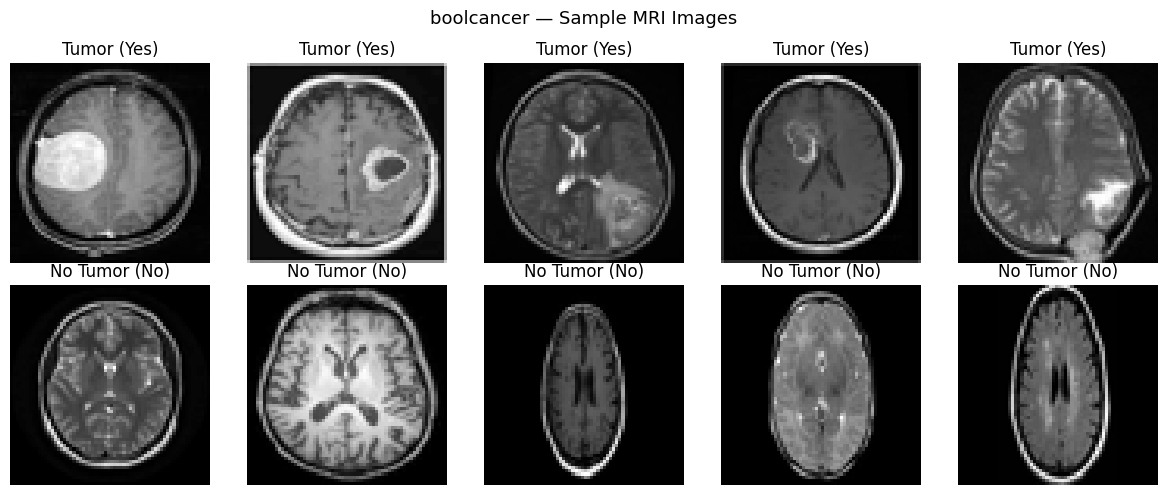

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes[0]):
    ax.imshow(boolcancer_yes[i].reshape(IMG_SIZE), cmap='gray')
    ax.set_title('Tumor (Yes)')
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    ax.imshow(boolcancer_no[i].reshape(IMG_SIZE), cmap='gray')
    ax.set_title('No Tumor (No)')
    ax.axis('off')
plt.suptitle('boolcancer — Sample MRI Images', fontsize=13)
plt.tight_layout()
plt.show()

**Model 1 — Base Logistic Regression**
This is the starting point. We take the raw pixel values, normalize them to 0–1, and feed them straight into a logistic regression. No feature engineering, no class balancing, just one train/test split. The goal here is to get a baseline number to compare everything else against.

## 3. Train / Test Split & Train Model on boolcancer

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bool, y_bool,
    test_size=0.20,
    random_state=42,
    stratify=y_bool
)

X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f'Training samples: {len(X_train)}')
print(f'Test samples    : {len(X_test)}')

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
print('Model trained!')

Training samples: 202
Test samples    : 51
Model trained!


## 4. Evaluate on boolcancer Test Set

=== Logistic Regression — boolcancer Test Set ===
Accuracy : 0.8431
Precision: 0.8485
Recall   : 0.9032
F1-Score : 0.8750

              precision    recall  f1-score   support

    No Tumor       0.83      0.75      0.79        20
       Tumor       0.85      0.90      0.88        31

    accuracy                           0.84        51
   macro avg       0.84      0.83      0.83        51
weighted avg       0.84      0.84      0.84        51



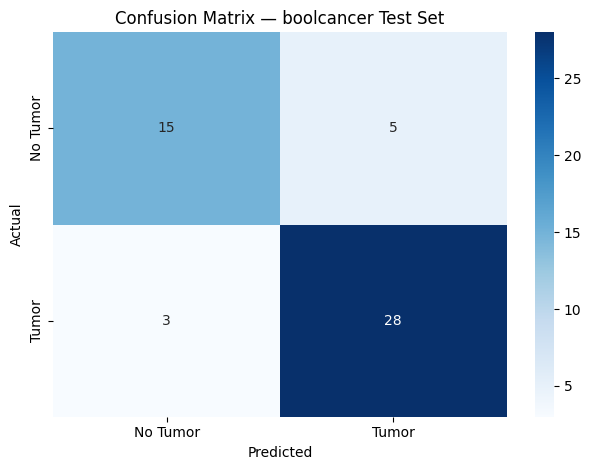

In [ ]:
y_pred = logreg_model.predict(X_test)

print('=== Logistic Regression — boolcancer Test Set ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix — boolcancer Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. Load 3types Dataset & Run Predictions

The model trained on boolcancer now predicts yes/no for each image in the 3types dataset.
Since not every slice will clearly show a tumor, we report what the model predicts for each type.

In [ ]:
types_3 = ['brain_glioma', 'brain_menin', 'brain_tumor']

types_images    = []
types_per_image = []

for class_name in types_3:
    folder = os.path.join(TYPES_PATH, class_name)
    for filename in sorted(os.listdir(folder)):
        filepath = os.path.join(folder, filename)
        try:
            img = Image.open(filepath).convert('L')
            img = img.resize(IMG_SIZE)
            types_images.append(np.array(img).flatten())
            types_per_image.append(class_name)
        except:
            pass

X_3types = np.array(types_images) / 255.0
print(f'Total 3types images loaded: {len(X_3types)}')
for name in types_3:
    print(f'  {name}: {types_per_image.count(name)} images')

Total 3types images loaded: 6056
  brain_glioma: 2004 images
  brain_menin: 2004 images
  brain_tumor: 2048 images


In [ ]:
y_3types_pred = logreg_model.predict(X_3types)
types_arr     = np.array(types_per_image)

print('=== Model Predictions on 3types Dataset ===')
print(f'Total images  : {len(y_3types_pred)}')
print(f'Predicted YES : {sum(y_3types_pred == 1)} ({sum(y_3types_pred == 1)/len(y_3types_pred)*100:.1f}%)')
print(f'Predicted NO  : {sum(y_3types_pred == 0)} ({sum(y_3types_pred == 0)/len(y_3types_pred)*100:.1f}%)')
print()

print('--- Breakdown by cancer type ---')
for name in types_3:
    mask      = types_arr == name
    preds     = y_3types_pred[mask]
    yes_count = sum(preds == 1)
    no_count  = sum(preds == 0)
    print(f'{name}: {yes_count} YES ({yes_count/sum(mask)*100:.1f}%)  |  {no_count} NO ({no_count/sum(mask)*100:.1f}%)')

=== Model Predictions on 3types Dataset ===
Total images  : 6056
Predicted YES : 3085 (50.9%)
Predicted NO  : 2971 (49.1%)

--- Breakdown by cancer type ---
brain_glioma: 898 YES (44.8%)  |  1106 NO (55.2%)
brain_menin: 1028 YES (51.3%)  |  976 NO (48.7%)
brain_tumor: 1159 YES (56.6%)  |  889 NO (43.4%)


3types images predicted as No Tumor: 2971


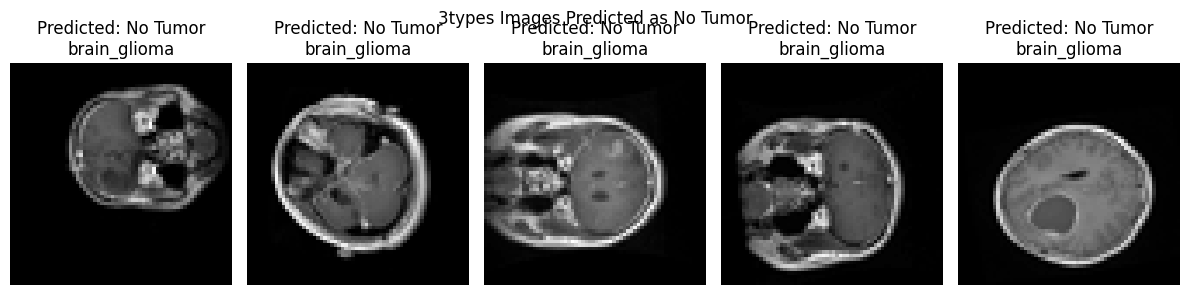

In [ ]:
no_pred_idx = np.where(y_3types_pred == 0)[0]
print(f'3types images predicted as No Tumor: {len(no_pred_idx)}')

if len(no_pred_idx) > 0:
    show = min(5, len(no_pred_idx))
    fig, axes = plt.subplots(1, show, figsize=(12, 3))
    if show == 1:
        axes = [axes]
    for i, idx in enumerate(no_pred_idx[:show]):
        axes[i].imshow(types_images[idx].reshape(IMG_SIZE), cmap='gray')
        axes[i].set_title(f'Predicted: No Tumor\n{types_per_image[idx]}')
        axes[i].axis('off')
    plt.suptitle('3types Images Predicted as No Tumor', fontsize=12)
    plt.tight_layout()
    plt.show()

**Model 2 — Improved Logistic Regression**
Same model as the past one. Added StandardScaler so the features are centered. used class_weight='balanced' as the dataset is a little skewed 155 tumor vs 98 none tumor. Switched to 5-foid cross-validation so F1 isn't based on one random split

## 5b. Improved Logistic Regression

Same idea as Section 3–5 but with three upgrades:
- **StandardScaler** — zero-centers and unit-variances features (better than /255 alone)
- **class_weight='balanced'** — corrects for the 155 tumor vs 98 no-tumor imbalance
- **5-fold cross-validation** — more reliable score than a single train/test split

Original LogReg — single split F1 : 0.8750
Improved LogReg — 5-fold CV F1    : 0.8445 ± 0.0380
Model trained!
=== Improved Logistic Regression — boolcancer Test Set ===
Accuracy : 0.8627
Precision: 0.8750
Recall   : 0.9032
F1-Score : 0.8889

              precision    recall  f1-score   support

    No Tumor       0.84      0.80      0.82        20
       Tumor       0.88      0.90      0.89        31

    accuracy                           0.86        51
   macro avg       0.86      0.85      0.85        51
weighted avg       0.86      0.86      0.86        51



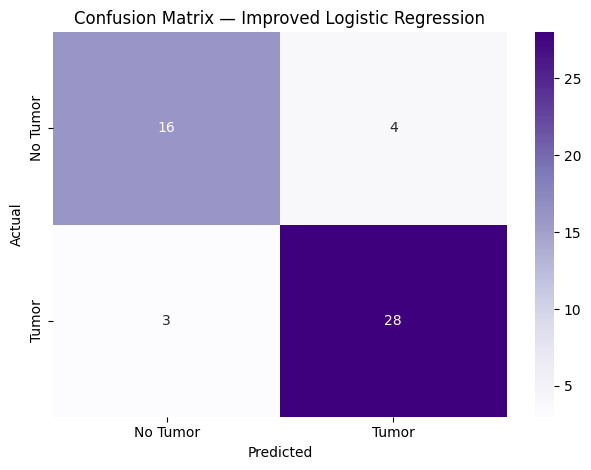

=== Improved LogReg Predictions on 3types Dataset ===
Total images  : 6056
Predicted YES : 3263 (53.9%)
Predicted NO  : 2793 (46.1%)

--- Breakdown by cancer type ---
brain_glioma: 1045 YES (52.1%)  |  959 NO (47.9%)
brain_menin: 1092 YES (54.5%)  |  912 NO (45.5%)
brain_tumor: 1126 YES (55.0%)  |  922 NO (45.0%)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

model_imp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_imp, X_bool / 255.0, y_bool, cv=cv, scoring='f1')

print(f'Original LogReg — single split F1 : {f1_score(y_test, y_pred):.4f}')
print(f'Improved LogReg — 5-fold CV F1    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

model_imp.fit(X_train, y_train)
print('Model trained!')

y_pred_imp = model_imp.predict(X_test)

print('=== Improved Logistic Regression — boolcancer Test Set ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_imp):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_imp):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_imp):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_imp):.4f}')
print()
print(classification_report(y_test, y_pred_imp, target_names=['No Tumor', 'Tumor']))

cm_imp = confusion_matrix(y_test, y_pred_imp)
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix — Improved Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

y_3types_imp  = model_imp.predict(X_3types)
types_arr_imp = np.array(types_per_image)

print('=== Improved LogReg Predictions on 3types Dataset ===')
print(f'Total images  : {len(y_3types_imp)}')
print(f'Predicted YES : {sum(y_3types_imp == 1)} ({sum(y_3types_imp == 1)/len(y_3types_imp)*100:.1f}%)')
print(f'Predicted NO  : {sum(y_3types_imp == 0)} ({sum(y_3types_imp == 0)/len(y_3types_imp)*100:.1f}%)')
print()

print('--- Breakdown by cancer type ---')
for name in types_3:
    mask      = types_arr_imp == name
    preds     = y_3types_imp[mask]
    yes_count = sum(preds == 1)
    no_count  = sum(preds == 0)
    print(f'{name}: {yes_count} YES ({yes_count/sum(mask)*100:.1f}%)  |  {no_count} NO ({no_count/sum(mask)*100:.1f}%)')

**Model 3 — CNN 1**
This model does two things. First, predicts the tumor type( Flioma, meningioma, or pituitary using a CNN built in TensorFlow/Keras trained on the full 3types dataset of 6056 images. Then it uses yes/no detctor using confidence. over 60% means Yes. It does classification, the output handes the binary decision.

#6. implementing CNN model


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from collections import Counter
le = LabelEncoder()
y_3types = le.fit_transform(types_per_image)

y_3types = to_categorical(y_3types, num_classes=3)
X_3types_cnn = X_3types.reshape(-1, 64, 64, 1)

In [ ]:

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_3types_cnn, y_3types, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.layers import GroupNormalization

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(64,64,1)))
model.add(GroupNormalization(groups=4))
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(GroupNormalization(groups=4))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(GroupNormalization(groups=4))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(GroupNormalization(groups=4))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(GroupNormalization(groups=4))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(GroupNormalization(groups=4))
model.add(layers.MaxPooling2D((2,2)))


model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(256, activation='relu'))
model.add(GroupNormalization(groups=4))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(3, activation='softmax'))



model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization             │ (None, 64, 64, 32)     │            64 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_1           │ (None, 64, 64, 32)     │            64 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_2           │ (None, 32, 32, 64)     │           128 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_3           │ (None, 32, 32, 64)     │           128 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_4           │ (None, 16, 16, 128)    │           256 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_5           │ (None, 16, 16, 128)    │           256 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ group_normalization_6           │ (None, 256)            │           512 │
│ (GroupNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,635 (1.23 MB)

 Trainable params: 321,635 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_3, y_train_3,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_3, y_test_3),
    callbacks=[early_stop]
)

Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.5976 - loss: 0.9464 - val_accuracy: 0.7706 - val_loss: 0.5653
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7550 - loss: 0.6035 - val_accuracy: 0.7401 - val_loss: 0.6074
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8000 - loss: 0.5011 - val_accuracy: 0.8218 - val_loss: 0.4238
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8241 - loss: 0.4383 - val_accuracy: 0.8630 - val_loss: 0.3559
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8441 - loss: 0.4000 - val_accuracy: 0.8614 - val_loss: 0.3488
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8722 - loss: 0.3305 - val_accuracy: 0.8449 - val_loss: 0.3830
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8832 - loss: 0.2968 - val_accuracy: 0.8663 - val_loss: 0.3306
Epoch 8/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9046 - loss: 0.2510 - val_acc

### Training History

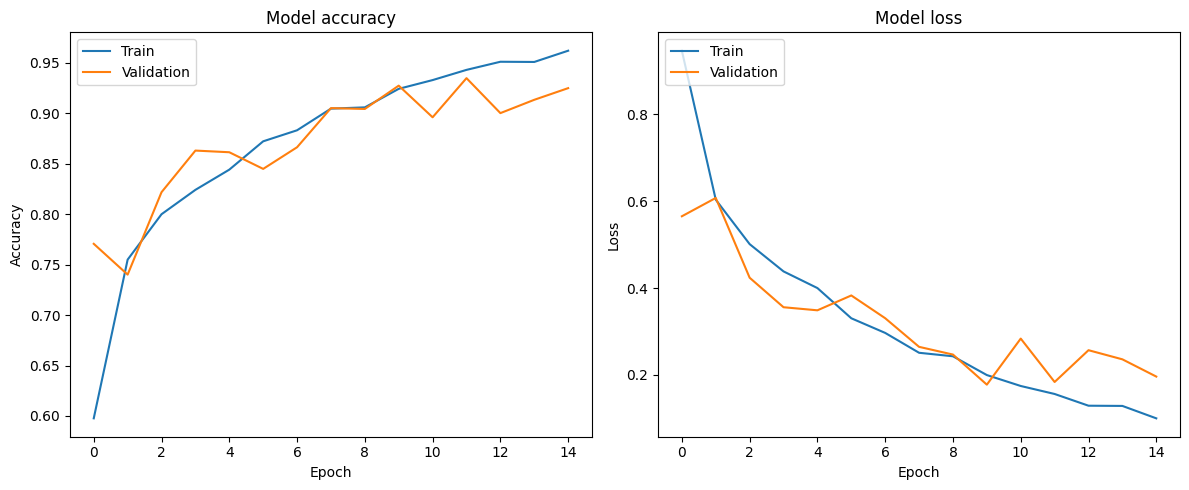

In [ ]:
plt.figure(figsize=(12, 5))

#Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

#Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:

y_pred_3 = np.argmax(model.predict(X_test_3), axis=1)
y_true_3 = np.argmax(y_test_3, axis=1)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


In [ ]:
predicted_labels = le.inverse_transform(y_pred_3)

In [ ]:
print(classification_report(y_true_3, y_pred_3, target_names=types_3))

              precision    recall  f1-score   support

brain_glioma       0.96      0.88      0.92       425
 brain_menin       0.87      0.93      0.90       392
 brain_tumor       0.95      0.98      0.96       395

    accuracy                           0.93      1212
   macro avg       0.93      0.93      0.93      1212
weighted avg       0.93      0.93      0.93      1212



In [ ]:
print("=== Model Predictions on 3types Dataset ===")

total = len(predicted_labels)
print(f"Total images  : {total}")

=== Model Predictions on 3types Dataset ===
Total images  : 1212


In [ ]:
pred_counts = Counter(predicted_labels)

for label in types_3:
    count = pred_counts[label]
    percent = (count / total) * 100
    print(f"Predicted {label.upper():<12}: {count} ({percent:.1f}%)")

Predicted BRAIN_GLIOMA: 388 (32.0%)
Predicted BRAIN_MENIN : 419 (34.6%)
Predicted BRAIN_TUMOR : 405 (33.4%)


In [ ]:
print("\n--- Breakdown by cancer type ---")

original_test_types = le.inverse_transform(y_true_3)

for cancer_type in types_3:

    indices_for_type_in_test = [i for i, t in enumerate(original_test_types) if t == cancer_type]
    preds_for_type = [predicted_labels[i] for i in indices_for_type_in_test]
    counts = Counter(preds_for_type)

    total_type = len(indices_for_type_in_test)

    print(f"\n{cancer_type}:")

    for label in types_3:
        count = counts[label]
        percent = (count / total_type) * 100
        print(f"  {label}: {count} ({percent:.1f}%)")


--- Breakdown by cancer type ---

brain_glioma:
  brain_glioma: 372 (87.5%)
  brain_menin: 49 (11.5%)
  brain_tumor: 4 (0.9%)

brain_menin:
  brain_glioma: 11 (2.8%)
  brain_menin: 366 (93.4%)
  brain_tumor: 15 (3.8%)

brain_tumor:
  brain_glioma: 5 (1.3%)
  brain_menin: 4 (1.0%)
  brain_tumor: 386 (97.7%)


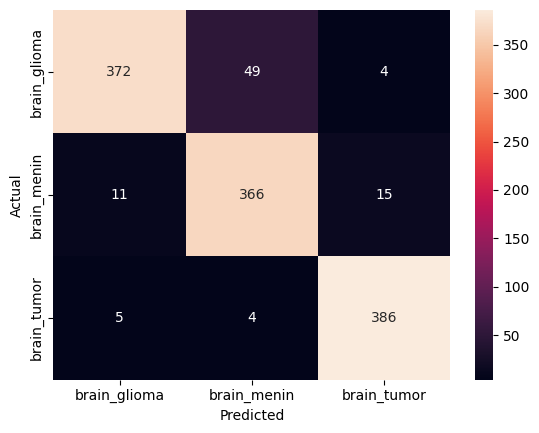

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_3, y_pred_3)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=types_3,
            yticklabels=types_3)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 6b. type_cnn_model — YES / NO Detection

Since type_cnn_model was only trained on tumor types, it has no concept of no tumor. To get a YES/NO answer we use the confidence score. If it's 60%+ confident it found a tumor type, that's YES, otherwise NO. This is a workaround. My 4-class model in Section 12 does it properly since it was trained with no-tumor images from the start.

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
=== type_cnn_model CNN — boolcancer Test Set ===
Accuracy : 0.5686
Precision: 0.5957
Recall   : 0.9032
F1-Score : 0.7179

              precision    recall  f1-score   support

    No Tumor       0.25      0.05      0.08        20
       Tumor       0.60      0.90      0.72        31

    accuracy                           0.57        51
   macro avg       0.42      0.48      0.40        51
weighted avg       0.46      0.57      0.47        51



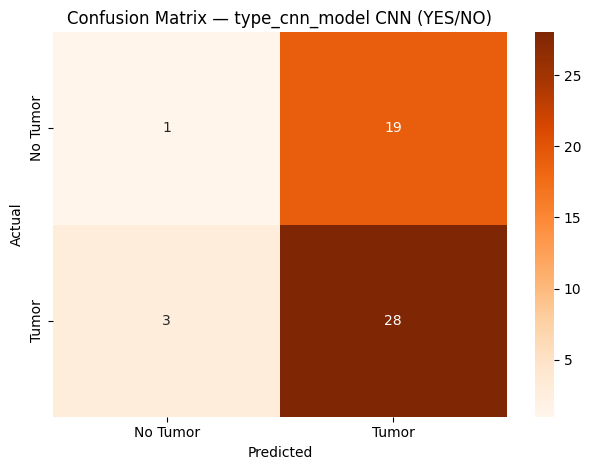

In [ ]:
X_test_cnn   = X_test.reshape(-1, 64, 64, 1)
probs_test   = model.predict(X_test_cnn)
conf_test    = np.max(probs_test, axis=1)
threshold    = 0.60
y_pred_yesno = (conf_test >= threshold).astype(int)

print('=== type_cnn_model CNN — boolcancer Test Set ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_yesno):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_yesno):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_yesno):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_yesno):.4f}')
print()
print(classification_report(y_test, y_pred_yesno, target_names=['No Tumor', 'Tumor']))

cm_team = confusion_matrix(y_test, y_pred_yesno)
sns.heatmap(cm_team, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix — type_cnn_model CNN (YES/NO)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# save reference so cross-testing section can use it
type_cnn_model = model

## 7. Deep Learning — Transfer Learning with ResNet18

**Step 1 (7a):** Use a pretrained ResNet18 as a feature extractor — feed 512-dim deep features into LogisticRegression instead of raw pixels

**Step 2 (7b):** Fine-tune ResNet18 end-to-end as a binary CNN classifier with data augmentation

In [ ]:
import torch
import torchvision.models as tv_models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


**Model 4 — ResNet18 Feature Extractor + Logistic Regression**

Instead of raw pixels, we pull 512 features from ResNet18's second-to-last layer and feed them into logistic regression. ResNet18 was pretrained on ImageNet so it already knows how to find patterns in images, so we don't just memorize.

### 7a. Deep Feature Extraction + Logistic Regression

In [ ]:
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

resnet_fe = tv_models.resnet18(weights='IMAGENET1K_V1')
feature_extractor = nn.Sequential(*list(resnet_fe.children())[:-1])
feature_extractor = feature_extractor.to(device).eval()

def extract_deep_features(folder, label):
    feats, labels = [], []
    for fname in sorted(os.listdir(folder)):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath).convert('RGB')
            t   = transform_eval(img).unsqueeze(0).to(device)
            with torch.no_grad():
                f = feature_extractor(t).squeeze().cpu().numpy()
            feats.append(f)
            labels.append(label)
        except:
            pass
    return feats, labels

yes_feats, yes_fl = extract_deep_features(BOOLCANCER_YES, 1)
no_feats,  no_fl  = extract_deep_features(BOOLCANCER_NO,  0)

X_deep = np.array(yes_feats + no_feats)
y_deep = np.array(yes_fl    + no_fl)
print(f'Deep feature matrix: {X_deep.shape}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


Deep feature matrix: (253, 512)


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

pipeline_deep = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

scores_base = cross_val_score(pipeline_baseline, X_bool / 255.0, y_bool, cv=cv, scoring='f1')
scores_deep = cross_val_score(pipeline_deep,     X_deep,         y_deep, cv=cv, scoring='f1')

print(f'Baseline (raw pixels) — 5-fold CV F1 : {scores_base.mean():.4f} ± {scores_base.std():.4f}')
print(f'Deep features (ResNet18) — 5-fold CV F1: {scores_deep.mean():.4f} ± {scores_deep.std():.4f}')

Baseline (raw pixels) — 5-fold CV F1 : 0.8445 ± 0.0380
Deep features (ResNet18) — 5-fold CV F1: 0.8620 ± 0.0393


**Model 5 — Fine-Tuned ResNet18 CNN**
We take ResNet18 and train it on our data in two phases — first just the final layer for 10 epochs, then all layers at a smaller learning rate. Dropout(0.5) and early stopping with patience=5 are added so it doesn't overfit on our 253 images.

### 7b. Fine-Tuned CNN (ResNet18 + Data Augmentation)

Phase 1: freeze all conv layers, train only the new head (10 epochs)
Phase 2: unfreeze everything, fine-tune at a smaller learning rate (20 epochs)

In [ ]:
class BrainTumorDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

def collect_paths(folder, label):
    paths, labels = [], []
    for fname in sorted(os.listdir(folder)):
        fpath = os.path.join(folder, fname)
        try:
            Image.open(fpath).verify()
            paths.append(fpath)
            labels.append(label)
        except:
            pass
    return paths, labels

yes_paths, yes_pl = collect_paths(BOOLCANCER_YES, 1)
no_paths,  no_pl  = collect_paths(BOOLCANCER_NO,  0)
all_paths  = yes_paths + no_paths
all_labels = yes_pl    + no_pl

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(BrainTumorDataset(train_paths, train_labels, transform_train),
                          batch_size=16, shuffle=True)
val_loader   = DataLoader(BrainTumorDataset(val_paths,   val_labels,   transform_val),
                          batch_size=16, shuffle=False)
print(f'Train: {len(train_paths)}, Val: {len(val_paths)}')

Train: 202, Val: 51


In [ ]:
cnn_model = tv_models.resnet18(weights='IMAGENET1K_V1')
for p in cnn_model.parameters():
    p.requires_grad = False
cnn_model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(512, 2))
cnn_model     = cnn_model.to(device)

class_weights = torch.tensor([1.0, len(no_pl) / len(yes_pl)]).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights)

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = correct = total = 0
    all_preds, all_probs, all_true = [], [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if training: loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            probs = torch.softmax(out, 1)[:, 1]
            preds = out.argmax(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
            all_true.extend(labels.detach().cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_probs, all_true

In [ ]:
train_losses, val_losses, train_accs, val_accs = [], [], [], []

optimizer1 = optim.Adam(cnn_model.fc.parameters(), lr=1e-3)
scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=5, gamma=0.5)

print('Phase 1 — training head only')
for epoch in range(10):
    tr_loss, tr_acc, *_ = run_epoch(cnn_model, train_loader, optimizer1)
    vl_loss, vl_acc, *_ = run_epoch(cnn_model, val_loader)
    scheduler1.step()
    train_losses.append(tr_loss); val_losses.append(vl_loss)
    train_accs.append(tr_acc);   val_accs.append(vl_acc)
    print(f'  Epoch {epoch+1:02d}/10 | Loss {tr_loss:.4f}/{vl_loss:.4f} | Acc {tr_acc:.4f}/{vl_acc:.4f}')

for p in cnn_model.parameters():
    p.requires_grad = True
optimizer2 = optim.Adam(cnn_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=20)

best_val_loss = float('inf')
patience      = 5
no_improve    = 0
best_weights  = None

print('\nPhase 2 — fine-tuning all layers (early stop patience=5)')
for epoch in range(20):
    tr_loss, tr_acc, *_ = run_epoch(cnn_model, train_loader, optimizer2)
    vl_loss, vl_acc, *_ = run_epoch(cnn_model, val_loader)
    scheduler2.step()
    train_losses.append(tr_loss); val_losses.append(vl_loss)
    train_accs.append(tr_acc);   val_accs.append(vl_acc)
    print(f'  Epoch {epoch+1:02d}/20 | Loss {tr_loss:.4f}/{vl_loss:.4f} | Acc {tr_acc:.4f}/{vl_acc:.4f}')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        no_improve    = 0
        best_weights  = {k: v.clone() for k, v in cnn_model.state_dict().items()}
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'  Early stop — restoring best weights')
            break

cnn_model.load_state_dict(best_weights)

Phase 1 — training head only
  Epoch 01/10 | Loss 0.7946/0.6289 | Acc 0.5347/0.6078
  Epoch 02/10 | Loss 0.6460/0.5391 | Acc 0.6337/0.6863
  Epoch 03/10 | Loss 0.5392/0.4887 | Acc 0.7376/0.7255
  Epoch 04/10 | Loss 0.6267/0.4807 | Acc 0.6683/0.8235
  Epoch 05/10 | Loss 0.5635/0.4416 | Acc 0.7673/0.7843
  Epoch 06/10 | Loss 0.5124/0.4369 | Acc 0.7673/0.7647
  Epoch 07/10 | Loss 0.5413/0.4181 | Acc 0.7327/0.8824
  Epoch 08/10 | Loss 0.4956/0.4525 | Acc 0.7327/0.7255
  Epoch 09/10 | Loss 0.4809/0.4223 | Acc 0.7475/0.8431
  Epoch 10/10 | Loss 0.4853/0.4208 | Acc 0.7822/0.8039

Phase 2 — fine-tuning all layers (early stop patience=5)
  Epoch 01/20 | Loss 0.4226/0.4725 | Acc 0.8020/0.8627
  Epoch 02/20 | Loss 0.2056/0.2249 | Acc 0.9158/0.9216
  Epoch 03/20 | Loss 0.1431/0.2033 | Acc 0.9703/0.9412
  Epoch 04/20 | Loss 0.0892/0.3420 | Acc 0.9752/0.8824
  Epoch 05/20 | Loss 0.0893/0.2102 | Acc 0.9653/0.9020
  Epoch 06/20 | Loss 0.0673/0.2009 | Acc 0.9802/0.9216
  Epoch 07/20 | Loss 0.0820/0.317

<All keys matched successfully>

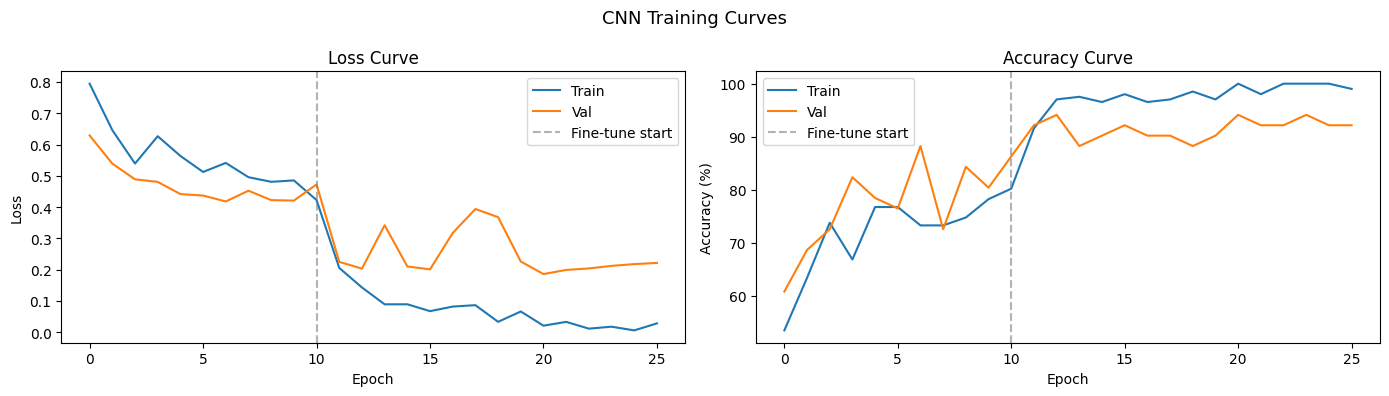

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title, ylabel in [
    (ax1, (train_losses, val_losses), 'Loss Curve',     'Loss'),
    (ax2, ([a*100 for a in train_accs], [a*100 for a in val_accs]), 'Accuracy Curve', 'Accuracy (%)'),
]:
    ax.plot(data[0], label='Train')
    ax.plot(data[1], label='Val')
    ax.axvline(x=10, color='gray', linestyle='--', alpha=0.6, label='Fine-tune start')
    ax.set(title=title, xlabel='Epoch', ylabel=ylabel)
    ax.legend()
plt.suptitle('CNN Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

=== CNN (ResNet18 Fine-Tuned) — Validation Set ===
Accuracy : 0.9412
Precision: 0.9667
Recall   : 0.9355
F1-Score : 0.9508
ROC-AUC  : 0.9823

              precision    recall  f1-score   support

    No Tumor       0.90      0.95      0.93        20
       Tumor       0.97      0.94      0.95        31

    accuracy                           0.94        51
   macro avg       0.94      0.94      0.94        51
weighted avg       0.94      0.94      0.94        51



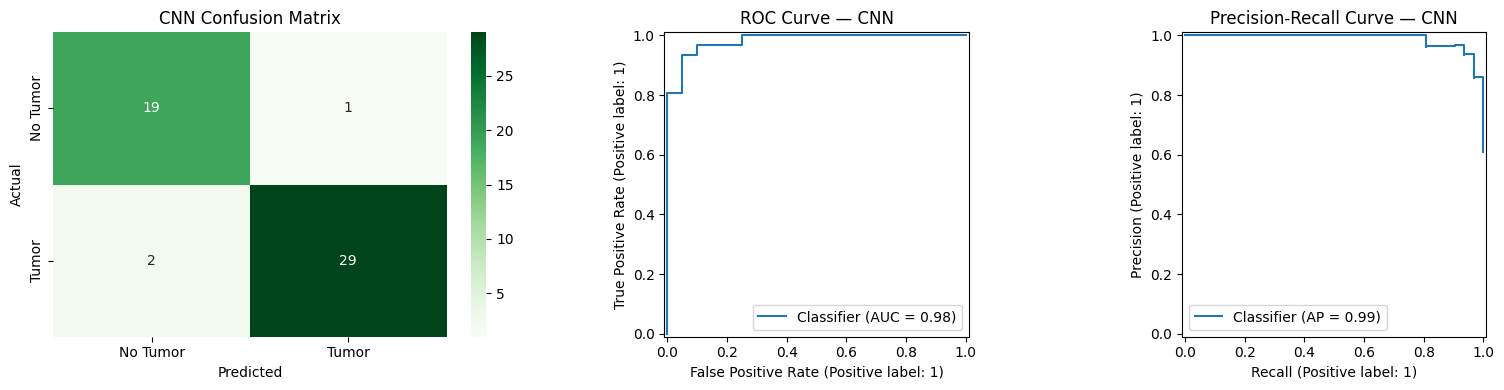

In [ ]:
_, _, cnn_preds, cnn_probs, cnn_true = run_epoch(cnn_model, val_loader)

print('=== CNN (ResNet18 Fine-Tuned) — Validation Set ===')
print(f'Accuracy : {accuracy_score(cnn_true, cnn_preds):.4f}')
print(f'Precision: {precision_score(cnn_true, cnn_preds):.4f}')
print(f'Recall   : {recall_score(cnn_true, cnn_preds):.4f}')
print(f'F1-Score : {f1_score(cnn_true, cnn_preds):.4f}')
print(f'ROC-AUC  : {roc_auc_score(cnn_true, cnn_probs):.4f}')
print()
print(classification_report(cnn_true, cnn_preds, target_names=['No Tumor', 'Tumor']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm = confusion_matrix(cnn_true, cnn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'], ax=axes[0])
axes[0].set(title='CNN Confusion Matrix', xlabel='Predicted', ylabel='Actual')

RocCurveDisplay.from_predictions(cnn_true, cnn_probs, ax=axes[1])
axes[1].set_title('ROC Curve — CNN')

PrecisionRecallDisplay.from_predictions(cnn_true, cnn_probs, ax=axes[2])
axes[2].set_title('Precision-Recall Curve — CNN')

plt.tight_layout()
plt.show()

## 8. Model Comparison

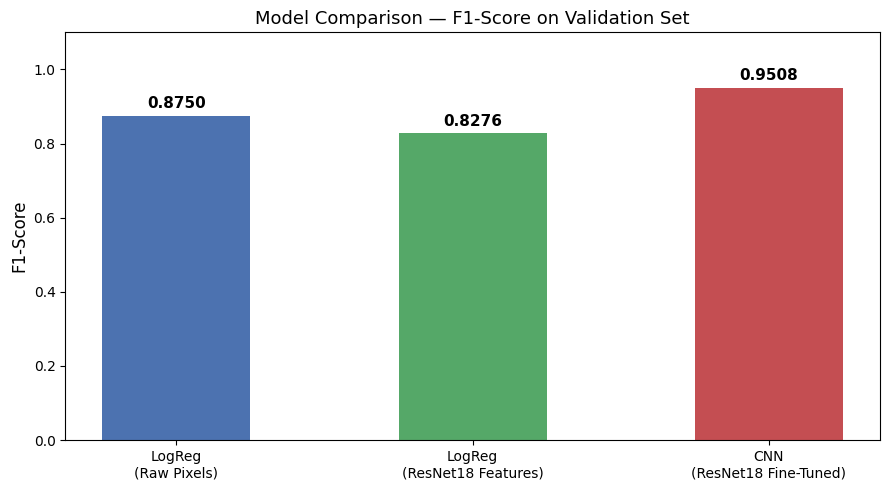

Method                     | F1-Score
----------------------------------------
LogReg (Raw Pixels)          | 0.8750
LogReg (ResNet18 Features)   | 0.8276
CNN (ResNet18 Fine-Tuned)    | 0.9508


In [ ]:
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_bool / 255.0, y_bool, test_size=0.2, random_state=42, stratify=y_bool
)
baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(X_train_b, y_train_b)
base_f1 = f1_score(y_val_b, baseline_lr.predict(X_val_b))

X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_deep, y_deep, test_size=0.2, random_state=42, stratify=y_deep
)
deep_lr = Pipeline([('scaler', StandardScaler()),
                    ('clf', LogisticRegression(class_weight='balanced',
                                              max_iter=1000, random_state=42))])
deep_lr.fit(X_train_d, y_train_d)
deep_f1 = f1_score(y_val_d, deep_lr.predict(X_val_d))

cnn_f1  = f1_score(cnn_true, cnn_preds)

methods = ['LogReg\n(Raw Pixels)', 'LogReg\n(ResNet18 Features)', 'CNN\n(ResNet18 Fine-Tuned)']
f1s     = [base_f1, deep_f1, cnn_f1]
colors  = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(methods, f1s, color=colors, width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Model Comparison — F1-Score on Validation Set', fontsize=13)
for bar, score in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Method                     | F1-Score')
print('-' * 40)
for m, s in zip(methods, f1s):
    print(f'{m.replace(chr(10), " "):<28} | {s:.4f}')

## 9. Apply Best Model (CNN) to 3types Dataset

The CNN trained on boolcancer now predicts yes/no for each image in the 3types dataset.

In [ ]:
class InferenceDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths     = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.paths[idx]).convert('RGB'))

types_paths_3 = []
types_names_3 = []

for cname in types_3:
    folder = os.path.join(TYPES_PATH, cname)
    for fname in sorted(os.listdir(folder)):
        fpath = os.path.join(folder, fname)
        try:
            Image.open(fpath).verify()
            types_paths_3.append(fpath)
            types_names_3.append(cname)
        except:
            pass

inf_loader = DataLoader(InferenceDataset(types_paths_3, transform_val),
                        batch_size=32, shuffle=False)

cnn_model.eval()
cnn_3types_preds = []
with torch.no_grad():
    for imgs in inf_loader:
        cnn_3types_preds.extend(cnn_model(imgs.to(device)).argmax(1).cpu().numpy())

cnn_3types_preds = np.array(cnn_3types_preds)
types_arr_3      = np.array(types_names_3)

print('=== CNN Predictions on 3-Types Dataset ===')
print(f'Total : {len(cnn_3types_preds)}')
print(f'YES   : {sum(cnn_3types_preds==1)} ({sum(cnn_3types_preds==1)/len(cnn_3types_preds)*100:.1f}%)')
print(f'NO    : {sum(cnn_3types_preds==0)} ({sum(cnn_3types_preds==0)/len(cnn_3types_preds)*100:.1f}%)')
print()
print('--- Breakdown by cancer type ---')
for name in types_3:
    mask  = types_arr_3 == name
    preds = cnn_3types_preds[mask]
    yes_c = sum(preds == 1); no_c = sum(preds == 0)
    print(f'{name}: {yes_c} YES ({yes_c/sum(mask)*100:.1f}%)  |  {no_c} NO ({no_c/sum(mask)*100:.1f}%)')

=== CNN Predictions on 3-Types Dataset ===
Total : 6056
YES   : 5336 (88.1%)
NO    : 720 (11.9%)

--- Breakdown by cancer type ---
brain_glioma: 1824 YES (91.0%)  |  180 NO (9.0%)
brain_menin: 1725 YES (86.1%)  |  279 NO (13.9%)
brain_tumor: 1787 YES (87.3%)  |  261 NO (12.7%)


## 10. Honest Evaluation on 3-Types Dataset

Since all 3-types images are confirmed tumors, we can measure real accuracy — the model should predict YES for all of them.
We do not add any Brain_Cancer images to training (that would be data leakage).

In [ ]:
y_true_3types = np.ones(len(cnn_3types_preds), dtype=int)

print('=== CNN — Honest 3-Types Evaluation (ground truth = all tumor) ===')
print(f'Overall Accuracy : {accuracy_score(y_true_3types, cnn_3types_preds):.4f}')
print()
print('--- Recall per tumor type (% correctly called YES) ---')
for name in ['brain_glioma', 'brain_menin', 'brain_tumor']:
    mask   = types_arr_3 == name
    preds  = cnn_3types_preds[mask]
    recall = sum(preds == 1) / sum(mask)
    missed = sum(preds == 0)
    print(f'{name}: {recall*100:.1f}% recall  ({missed} missed / {sum(mask)} total)')

=== CNN — Honest 3-Types Evaluation (ground truth = all tumor) ===
Overall Accuracy : 0.8811

--- Recall per tumor type (% correctly called YES) ---
brain_glioma: 91.0% recall  (180 missed / 2004 total)
brain_menin: 86.1% recall  (279 missed / 2004 total)
brain_tumor: 87.3% recall  (261 missed / 2048 total)


In [ ]:
print('=== Summary ===')
print('Model trained on 253 boolcancer images (yes/no).')
print('Evaluated blind on 6056 confirmed tumor images across 3 types.')
print('Lower recall on a type = model has not seen that tumor pattern before.')

=== Summary ===
Model trained on 253 boolcancer images (yes/no).
Evaluated blind on 6056 confirmed tumor images across 3 types.
Lower recall on a type = model has not seen that tumor pattern before.


## 11. Healthy Control Check

Run the same model on the boolcancer/no images (confirmed healthy) to make sure it is not just predicting YES for everything.

In [ ]:
ctrl_paths, ctrl_names = [], []
for fname in sorted(os.listdir(BOOLCANCER_NO)):
    fpath = os.path.join(BOOLCANCER_NO, fname)
    try:
        Image.open(fpath).verify()
        ctrl_paths.append(fpath)
        ctrl_names.append('healthy_control')
    except:
        pass

all_inf_paths = types_paths_3 + ctrl_paths
all_inf_names = types_names_3  + ctrl_names

inf_loader2 = DataLoader(InferenceDataset(all_inf_paths, transform_val),
                         batch_size=32, shuffle=False)

cnn_model.eval()
inf_preds = []
with torch.no_grad():
    for imgs in inf_loader2:
        inf_preds.extend(cnn_model(imgs.to(device)).argmax(1).cpu().numpy())

inf_preds = np.array(inf_preds)
inf_names = np.array(all_inf_names)

print('=== CNN — 3-Types + Healthy Control ===')
for name in ['brain_glioma', 'brain_menin', 'brain_tumor', 'healthy_control']:
    mask  = inf_names == name
    yes_c = sum(inf_preds[mask] == 1)
    no_c  = sum(inf_preds[mask] == 0)
    total = sum(mask)
    print(f'{name:<20}: {yes_c} YES ({yes_c/total*100:.1f}%)  |  {no_c} NO ({no_c/total*100:.1f}%)')

=== CNN — 3-Types + Healthy Control ===
brain_glioma        : 1824 YES (91.0%)  |  180 NO (9.0%)
brain_menin         : 1725 YES (86.1%)  |  279 NO (13.9%)
brain_tumor         : 1787 YES (87.3%)  |  261 NO (12.7%)
healthy_control     : 1 YES (1.0%)  |  97 NO (99.0%)


**Model 6 — 4-Class ResNet18 (No Tumor / Glioma / Menin / Pituitary)**

This model does both tasks in one shot, it tells you if there is a tumor AND which type it is. It's trained on the same 6,056 tumor images type_cnn_model used, plus the 98 no-tumor images from boolcancer. Since it uses pretrained ResNet18 instead of a CNN from scratch, it should outperform type_cnn_model on tumor type classification while also handling YES/NO natively.

## 12. 4-Class ResNet18 — No Tumor / Glioma / Menin / Pituitary

In [ ]:
# 0 = No Tumor, 1 = Glioma, 2 = Menin, 3 = Pituitary
class_names_4 = ['No Tumor', 'brain_glioma', 'brain_menin', 'brain_tumor']

no_paths_4,  no_labels_4  = collect_paths(BOOLCANCER_NO, 0)
gl_paths_4,  gl_labels_4  = collect_paths(os.path.join(TYPES_PATH, 'brain_glioma'),  1)
mn_paths_4,  mn_labels_4  = collect_paths(os.path.join(TYPES_PATH, 'brain_menin'),   2)
pt_paths_4,  pt_labels_4  = collect_paths(os.path.join(TYPES_PATH, 'brain_tumor'),   3)

all_paths_4  = no_paths_4  + gl_paths_4  + mn_paths_4  + pt_paths_4
all_labels_4 = no_labels_4 + gl_labels_4 + mn_labels_4 + pt_labels_4

train_paths_4, val_paths_4, train_labels_4, val_labels_4 = train_test_split(
    all_paths_4, all_labels_4, test_size=0.2, random_state=42, stratify=all_labels_4
)

train_loader_4 = DataLoader(BrainTumorDataset(train_paths_4, train_labels_4, transform_train),
                            batch_size=16, shuffle=True)
val_loader_4   = DataLoader(BrainTumorDataset(val_paths_4,   val_labels_4,   transform_val),
                            batch_size=16, shuffle=False)

print(f'Train: {len(train_paths_4)}, Val: {len(val_paths_4)}')
for i, name in enumerate(class_names_4):
    print(f'  {name}: {all_labels_4.count(i)} images')

Train: 4923, Val: 1231
  No Tumor: 98 images
  brain_glioma: 2004 images
  brain_menin: 2004 images
  brain_tumor: 2048 images


In [ ]:
cnn_model4 = tv_models.resnet18(weights='IMAGENET1K_V1')
for p in cnn_model4.parameters():
    p.requires_grad = False
cnn_model4.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(512, 4))
cnn_model4     = cnn_model4.to(device)

# weight no-tumor class higher since it only has 98 images vs 2000+ per tumor type
counts_4      = [len(no_paths_4), len(gl_paths_4), len(mn_paths_4), len(pt_paths_4)]
total_4       = sum(counts_4)
weights_4     = torch.tensor([total_4 / (4 * c) for c in counts_4], dtype=torch.float).to(device)
criterion4    = nn.CrossEntropyLoss(weight=weights_4)

def run_epoch4(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = correct = total = 0
    all_preds, all_true = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion4(out, labels)
            if training: loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_true.extend(labels.detach().cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_true

In [ ]:
train_losses_4, val_losses_4, train_accs_4, val_accs_4 = [], [], [], []

optimizer4a = optim.Adam(cnn_model4.fc.parameters(), lr=1e-3)
scheduler4a = optim.lr_scheduler.StepLR(optimizer4a, step_size=5, gamma=0.5)

print('Phase 1 — training head only')
for epoch in range(10):
    tr_loss, tr_acc, *_ = run_epoch4(cnn_model4, train_loader_4, optimizer4a)
    vl_loss, vl_acc, *_ = run_epoch4(cnn_model4, val_loader_4)
    scheduler4a.step()
    train_losses_4.append(tr_loss); val_losses_4.append(vl_loss)
    train_accs_4.append(tr_acc);   val_accs_4.append(vl_acc)
    print(f'  Epoch {epoch+1:02d}/10 | Loss {tr_loss:.4f}/{vl_loss:.4f} | Acc {tr_acc:.4f}/{vl_acc:.4f}')

for p in cnn_model4.parameters():
    p.requires_grad = True
optimizer4b = optim.Adam(cnn_model4.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler4b = optim.lr_scheduler.CosineAnnealingLR(optimizer4b, T_max=20)

best_val_loss4 = float('inf')
patience4      = 5
no_improve4    = 0
best_weights4  = None

print('\nPhase 2 — fine-tuning all layers (early stop patience=5)')
for epoch in range(20):
    tr_loss, tr_acc, *_ = run_epoch4(cnn_model4, train_loader_4, optimizer4b)
    vl_loss, vl_acc, *_ = run_epoch4(cnn_model4, val_loader_4)
    scheduler4b.step()
    train_losses_4.append(tr_loss); val_losses_4.append(vl_loss)
    train_accs_4.append(tr_acc);   val_accs_4.append(vl_acc)
    print(f'  Epoch {epoch+1:02d}/20 | Loss {tr_loss:.4f}/{vl_loss:.4f} | Acc {tr_acc:.4f}/{vl_acc:.4f}')

    if vl_loss < best_val_loss4:
        best_val_loss4 = vl_loss
        no_improve4    = 0
        best_weights4  = {k: v.clone() for k, v in cnn_model4.state_dict().items()}
    else:
        no_improve4 += 1
        if no_improve4 >= patience4:
            print(f'  Early stop — restoring best weights')
            break

cnn_model4.load_state_dict(best_weights4)

Phase 1 — training head only
  Epoch 01/10 | Loss 0.8619/0.4710 | Acc 0.6610/0.8603
  Epoch 02/10 | Loss 0.5937/0.3779 | Acc 0.7558/0.8611
  Epoch 03/10 | Loss 0.5411/0.3359 | Acc 0.7723/0.8741
  Epoch 04/10 | Loss 0.5090/0.2979 | Acc 0.7843/0.9066
  Epoch 05/10 | Loss 0.5293/0.3358 | Acc 0.7843/0.8603
  Epoch 06/10 | Loss 0.4790/0.2955 | Acc 0.7934/0.8993
  Epoch 07/10 | Loss 0.4665/0.2947 | Acc 0.8030/0.8928
  Epoch 08/10 | Loss 0.4820/0.2804 | Acc 0.7934/0.9009
  Epoch 09/10 | Loss 0.4901/0.3060 | Acc 0.7946/0.8871
  Epoch 10/10 | Loss 0.4761/0.2666 | Acc 0.7961/0.9123

Phase 2 — fine-tuning all layers (early stop patience=5)
  Epoch 01/20 | Loss 0.2430/0.0463 | Acc 0.9025/0.9740
  Epoch 02/20 | Loss 0.1099/0.0557 | Acc 0.9571/0.9756
  Epoch 03/20 | Loss 0.1245/0.0373 | Acc 0.9561/0.9862
  Epoch 04/20 | Loss 0.0553/0.0417 | Acc 0.9785/0.9813
  Epoch 05/20 | Loss 0.0492/0.0581 | Acc 0.9797/0.9781
  Epoch 06/20 | Loss 0.0393/0.0096 | Acc 0.9866/0.9943
  Epoch 07/20 | Loss 0.0567/0.044

<All keys matched successfully>

=== 4-Class ResNet18 — Validation Set ===
              precision    recall  f1-score   support

    No Tumor       1.00      1.00      1.00        19
brain_glioma       1.00      1.00      1.00       401
 brain_menin       1.00      1.00      1.00       401
 brain_tumor       1.00      1.00      1.00       410

    accuracy                           1.00      1231
   macro avg       1.00      1.00      1.00      1231
weighted avg       1.00      1.00      1.00      1231



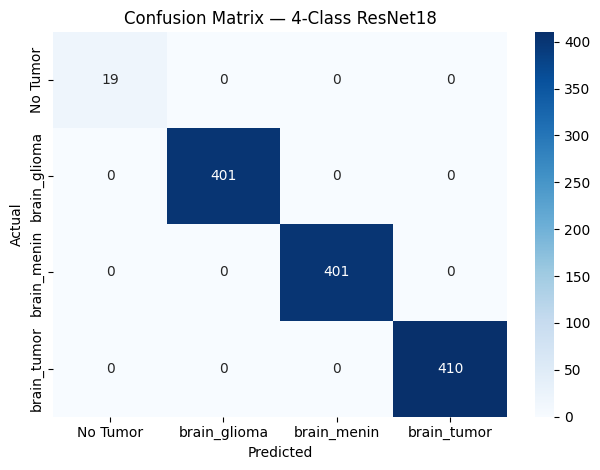

In [ ]:
_, _, preds4, true4 = run_epoch4(cnn_model4, val_loader_4)
preds4 = np.array(preds4)
true4  = np.array(true4)

print('=== 4-Class ResNet18 — Validation Set ===')
print(classification_report(true4, preds4, target_names=class_names_4))

cm4 = confusion_matrix(true4, preds4)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_4, yticklabels=class_names_4)
plt.title('Confusion Matrix — 4-Class ResNet18')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

=== 4-Class ResNet18 — YES/NO Detection ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

              precision    recall  f1-score   support

    No Tumor       1.00      1.00      1.00        19
       Tumor       1.00      1.00      1.00      1212

    accuracy                           1.00      1231
   macro avg       1.00      1.00      1.00      1231
weighted avg       1.00      1.00      1.00      1231



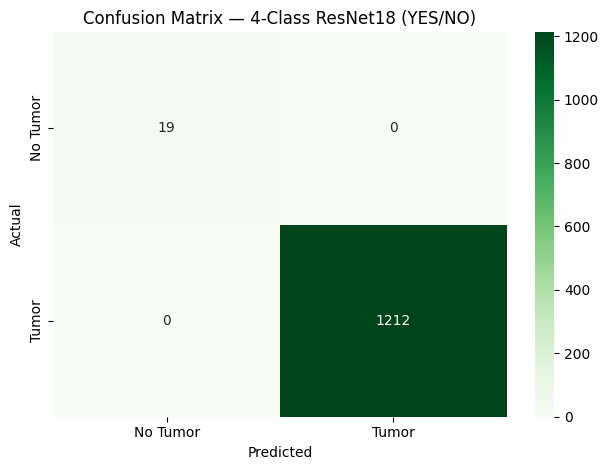

In [ ]:
# YES/NO from 4-class: class 0 = NO, anything else = YES
y_pred_4_yesno = (preds4 != 0).astype(int)
y_true_4_yesno = (true4  != 0).astype(int)

print('=== 4-Class ResNet18 — YES/NO Detection ===')
print(f'Accuracy : {accuracy_score(y_true_4_yesno, y_pred_4_yesno):.4f}')
print(f'Precision: {precision_score(y_true_4_yesno, y_pred_4_yesno):.4f}')
print(f'Recall   : {recall_score(y_true_4_yesno, y_pred_4_yesno):.4f}')
print(f'F1-Score : {f1_score(y_true_4_yesno, y_pred_4_yesno):.4f}')
print()
print(classification_report(y_true_4_yesno, y_pred_4_yesno, target_names=['No Tumor', 'Tumor']))

cm4_yesno = confusion_matrix(y_true_4_yesno, y_pred_4_yesno)
sns.heatmap(cm4_yesno, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix — 4-Class ResNet18 (YES/NO)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 13. Head-to-Head — Tumor Type Classification

In [ ]:
# Run my 4-class model on the val set — already done (preds4, true4)
# Run type_cnn_model on the same 3-types test images for a fair comparison

# type_cnn_model: get type predictions on the 3-types val set
# (X_test_3 and y_test_3 are from his train/test split in Section 6)
y_pred_tm   = np.argmax(type_cnn_model.predict(X_test_3), axis=1)
y_true_tm   = np.argmax(y_test_3, axis=1)

print('=== type_cnn_model CNN — Tumor Type Classification ===')
print(classification_report(y_true_tm, y_pred_tm, target_names=types_3))

print('=== My 4-Class ResNet18 — Tumor Type Classification ===')
# only look at the tumor-type predictions (exclude no-tumor class 0)
mask_tumor = true4 != 0
print(classification_report(true4[mask_tumor] - 1, preds4[mask_tumor] - 1, target_names=types_3))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
=== type_cnn_model CNN — Tumor Type Classification ===
              precision    recall  f1-score   support

brain_glioma       0.96      0.88      0.92       425
 brain_menin       0.87      0.93      0.90       392
 brain_tumor       0.95      0.98      0.96       395

    accuracy                           0.93      1212
   macro avg       0.93      0.93      0.93      1212
weighted avg       0.93      0.93      0.93      1212

=== My 4-Class ResNet18 — Tumor Type Classification ===
              precision    recall  f1-score   support

brain_glioma       1.00      1.00      1.00       401
 brain_menin       1.00      1.00      1.00       401
 brain_tumor       1.00      1.00      1.00       410

    accuracy                           1.00      1212
   macro avg       1.00      1.00      1.00      1212
weighted avg       1.00      1.00      1.00      1212



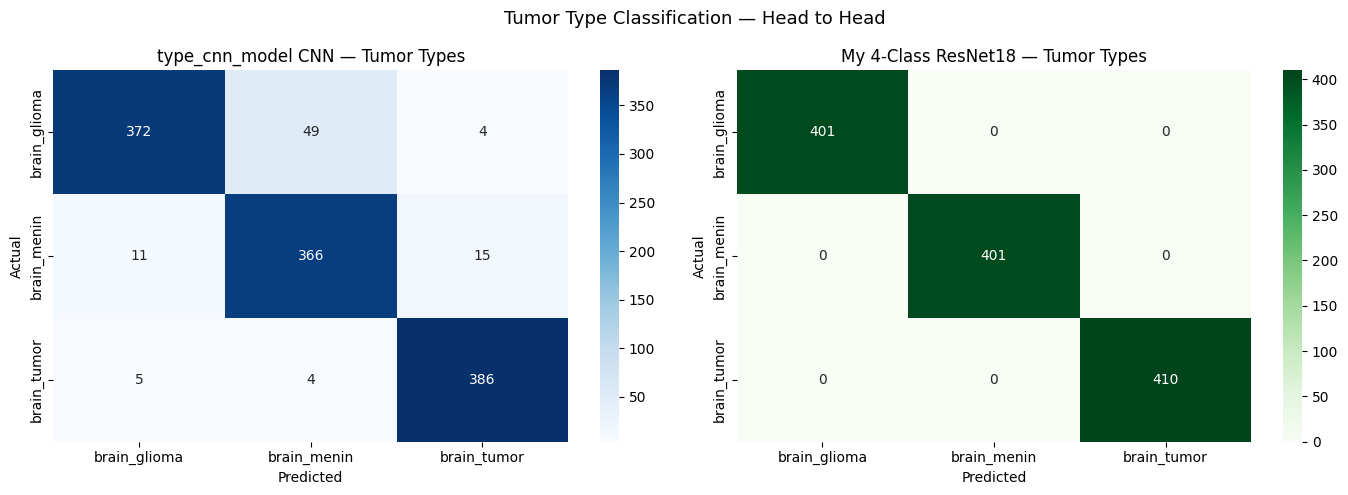

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_tm = confusion_matrix(y_true_tm, y_pred_tm)
sns.heatmap(cm_tm, annot=True, fmt='d', cmap='Blues',
            xticklabels=types_3, yticklabels=types_3, ax=axes[0])
axes[0].set_title('type_cnn_model CNN — Tumor Types')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

mask_tumor = true4 != 0
cm_me = confusion_matrix(true4[mask_tumor] - 1, preds4[mask_tumor] - 1)
sns.heatmap(cm_me, annot=True, fmt='d', cmap='Greens',
            xticklabels=types_3, yticklabels=types_3, ax=axes[1])
axes[1].set_title('My 4-Class ResNet18 — Tumor Types')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle('Tumor Type Classification — Head to Head', fontsize=13)
plt.tight_layout()
plt.show()

## 14. Head-to-Head — YES / NO Detection

In [ ]:
# YES/NO from confidence threshold
X_test_cnn_tm = X_test.reshape(-1, 64, 64, 1)

probs_tm_yn = type_cnn_model.predict(X_test_cnn_tm)
conf_tm_yn = np.max(probs_tm_yn, axis=1)
y_pred_tm_yn = (conf_tm_yn >= 0.60).astype(int)

# 4-class YES/NO on boolcancer test set
cnn_model4.eval()

X_test_t = torch.stack([
    transform_val(Image.open(p).convert('RGB')) for p in val_paths
]).to(device)

with torch.no_grad():
    preds4_yn = cnn_model4(X_test_t).argmax(1).cpu().numpy()

# class 0 = no tumor, anything else = tumor
y_pred4_yn = (preds4_yn != 0).astype(int)

print('=== YES/NO Detection — boolcancer Test Set ===')
print(f"{'Model':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('-' * 62)

for name, y_pred in [
    ('My Binary CNN (ResNet18)', np.array(cnn_preds)),
    ('My 4-Class CNN (ResNet18)', y_pred4_yn),
    ('CNN Confidence Threshold', y_pred_tm_yn),
]:
    print(f'{name:<30} {accuracy_score(y_test, y_pred):>10.4f} '
          f'{precision_score(y_test, y_pred):>10.4f} '
          f'{recall_score(y_test, y_pred):>10.4f} '
          f'{f1_score(y_test, y_pred):>10.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
=== YES/NO Detection — boolcancer Test Set ===
Model                            Accuracy  Precision     Recall         F1
--------------------------------------------------------------
My Binary CNN (ResNet18)           0.9412     0.9667     0.9355     0.9508
My 4-Class CNN (ResNet18)          0.4314     1.0000     0.0645     0.1212
CNN Confidence Threshold           0.5686     0.5957     0.9032     0.7179


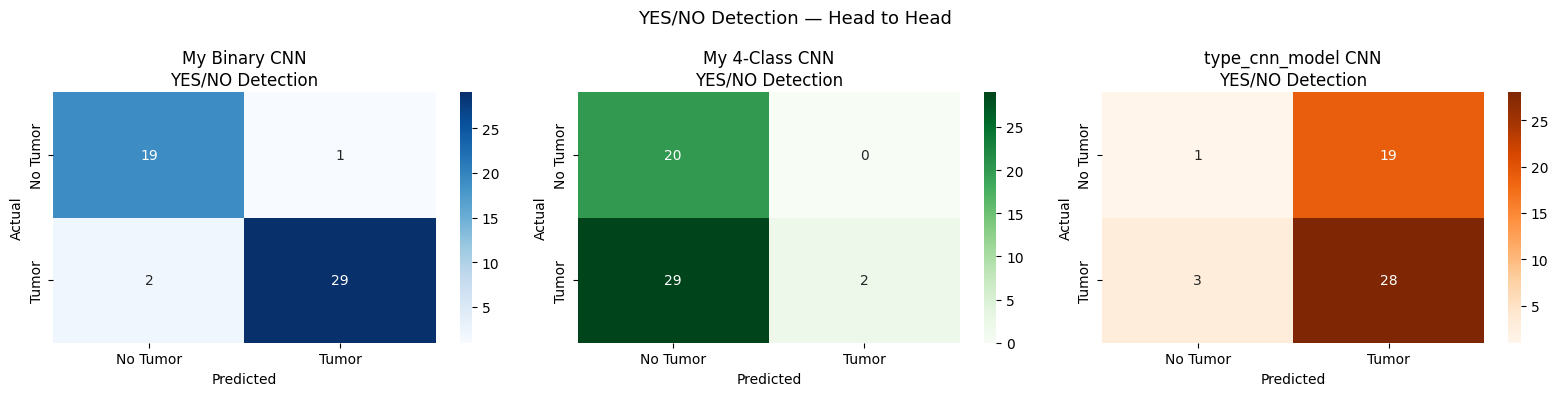

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, y_pred, cmap in [
    (axes[0], 'My Binary CNN',      np.array(cnn_preds), 'Blues'),
    (axes[1], 'My 4-Class CNN',     y_pred4_yn,          'Greens'),
    (axes[2], 'type_cnn_model CNN',       y_pred_tm_yn,        'Oranges'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No Tumor', 'Tumor'],
                yticklabels=['No Tumor', 'Tumor'], ax=ax)
    ax.set_title(f'{name}\nYES/NO Detection')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('YES/NO Detection — Head to Head', fontsize=13)
plt.tight_layout()
plt.show()

## 15. Final Model Comparison

All 6 models evaluated on the boolcancer test set for YES/NO detection. Shows the progression from the baseline logistic regression to the final 4-class ResNet18.

```latex
\begin{table}[h]
  \caption{Comparison Between Logistic Regression and CNN}
  \label{tab:comparison}
  \centering
  \setlength{\tabcolsep}{4pt} % Reduced column separation
  \begin{tabular}{lccc}
    \toprule
    Feature & Logistic Regression & CNN & ResNet18 CNN \\
    \midrule
    Feature Extraction   & Manual     & Automatic & Automatic (Pretrained) \\
    Spatial Awareness    & No         & Yes & Yes \\
    Model Complexity     & Low        & High & Very High \\
    Training Time        & Low        & High & Moderate (Transfer Learning) \\
    Accuracy Potential   & Moderate   & High & Very High \\
    Interpretability     & High       & Moderate & Low \\
    \bottomrule
  \end{tabular}
\end{table}
```

In [ ]:
import pandas as pd

# --- collect YES/NO predictions for all models on the same boolcancer test set ---

# Model 1: Base LogReg
p1 = logreg_model.predict(X_test)

# Model 2: Improved LogReg
p2 = model_imp.predict(X_test)

# Model 3: type_cnn_model (confidence threshold)
probs3   = type_cnn_model.predict(X_test.reshape(-1, 64, 64, 1))
p3       = (np.max(probs3, axis=1) >= 0.60).astype(int)

# Model 4: ResNet18 Features + LogReg
X_test_d = []
for p in val_paths:
    img = Image.open(p).convert('RGB')
    t   = transform_eval(img).unsqueeze(0).to(device)
    with torch.no_grad():
        f = feature_extractor(t).squeeze().cpu().numpy()
    X_test_d.append(f)
X_test_d = np.array(X_test_d)
p4 = deep_lr.predict(X_test_d)

# Model 5: Fine-Tuned ResNet18 CNN (binary)
p5 = np.array(cnn_preds)

# Model 6: 4-Class ResNet18
cnn_model4.eval()
imgs_test = torch.stack([transform_val(Image.open(p).convert('RGB')) for p in val_paths]).to(device)
with torch.no_grad():
    p6 = (cnn_model4(imgs_test).argmax(1).cpu().numpy() != 0).astype(int)

# --- build comparison table ---
rows = []
for name, preds in [
    ('Model 1 — Base LogReg',              p1),
    ('Model 2 — Improved LogReg',           p2),
    ('Model 3 — type_cnn_model (YES/NO)',   p3),
    ('Model 4 — ResNet18 Features + LogReg',p4),
    ('Model 5 — Fine-Tuned ResNet18 CNN',   p5),
    ('Model 6 — 4-Class ResNet18',          p6),
]:
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test,  preds), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test,    preds, zero_division=0), 4),
        'F1'       : round(f1_score(y_test,        preds, zero_division=0), 4),
    })

df = pd.DataFrame(rows).set_index('Model')
print('=== Final Model Comparison — boolcancer Test Set (YES/NO) ===')
print(df.to_string())

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
=== Final Model Comparison — boolcancer Test Set (YES/NO) ===
                                      Accuracy  Precision  Recall      F1
Model                                                                    
Model 1 — Base LogReg                   0.8431     0.8485  0.9032  0.8750
Model 2 — Improved LogReg               0.8627     0.8750  0.9032  0.8889
Model 3 — type_cnn_model (YES/NO)       0.5686     0.5957  0.9032  0.7179
Model 4 — ResNet18 Features + LogReg    0.8039     0.8889  0.7742  0.8276
Model 5 — Fine-Tuned ResNet18 CNN       0.9412     0.9667  0.9355  0.9508
Model 6 — 4-Class ResNet18              0.4314     1.0000  0.0645  0.1212


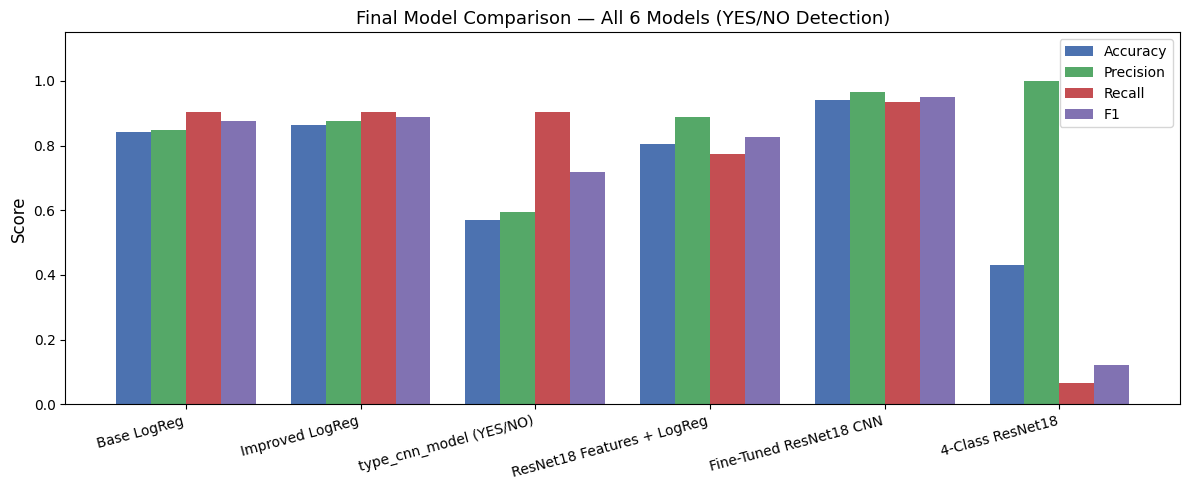

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(df))
w      = 0.2
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1'], colors)):
    bars = ax.bar(x + i*w, df[metric], w, label=metric, color=color)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels([r.split('—')[1].strip() for r in df.index], rotation=15, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Model Comparison — All 6 Models (YES/NO Detection)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

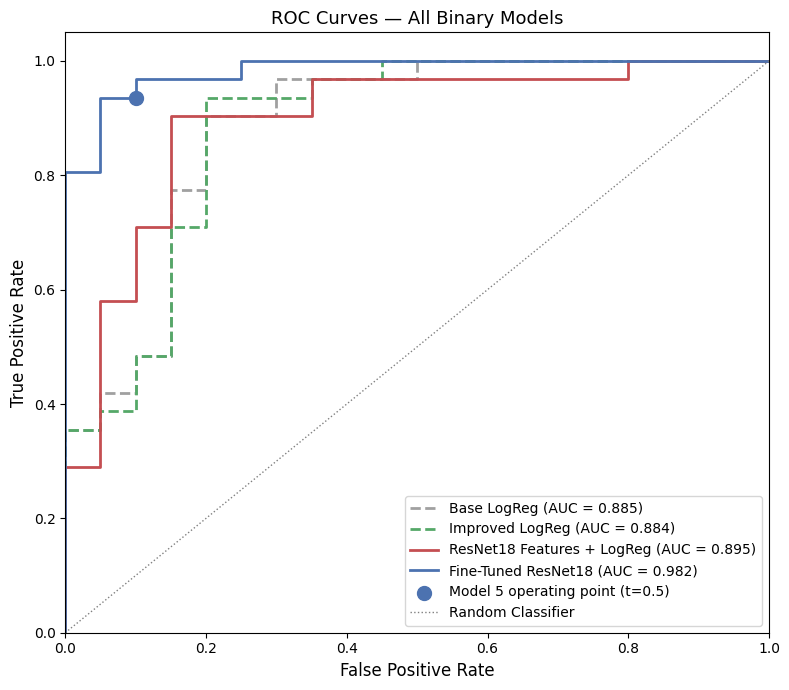

In [ ]:
from sklearn.metrics import roc_curve, auc

# Model 1 — Base LogReg
probs1 = logreg_model.predict_proba(X_test / 255.0)[:, 1]

# Model 2 — Improved LogReg
probs2 = model_imp.predict_proba(X_test / 255.0)[:, 1]

# Model 4 — ResNet18 Features + LogReg
feature_extractor.eval()
feats4 = []
with torch.no_grad():
    for p in val_paths:
        t = transform_eval(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
        feats4.append(feature_extractor(t).squeeze().cpu().numpy())
probs4 = deep_lr.predict_proba(np.array(feats4))[:, 1]

# Model 5 — Fine-Tuned ResNet18


models_roc = [
    ("Base LogReg",              np.array(cnn_true), probs1,              "#a0a0a0", "--"),
    ("Improved LogReg",          np.array(cnn_true), probs2,              "#55A868", "--"),
    ("ResNet18 Features + LogReg", np.array(cnn_true), probs4,            "#C44E52", "-"),
    ("Fine-Tuned ResNet18",      np.array(cnn_true), np.array(cnn_probs), "#4C72B0", "-"),
]

plt.figure(figsize=(8, 7))
for name, y_true, y_probs, color, ls in models_roc:
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, linestyle=ls, label=f"{name} (AUC = {roc_auc:.3f})")

from sklearn.metrics import roc_curve
fpr5, tpr5, thresh5 = roc_curve(np.array(cnn_true), np.array(cnn_probs))
op_idx = np.argmin(np.abs(thresh5 - 0.5))
plt.scatter(fpr5[op_idx], tpr5[op_idx], color="#4C72B0", s=100, zorder=5, label="Model 5 operating point (t=0.5)")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Binary Models", fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()


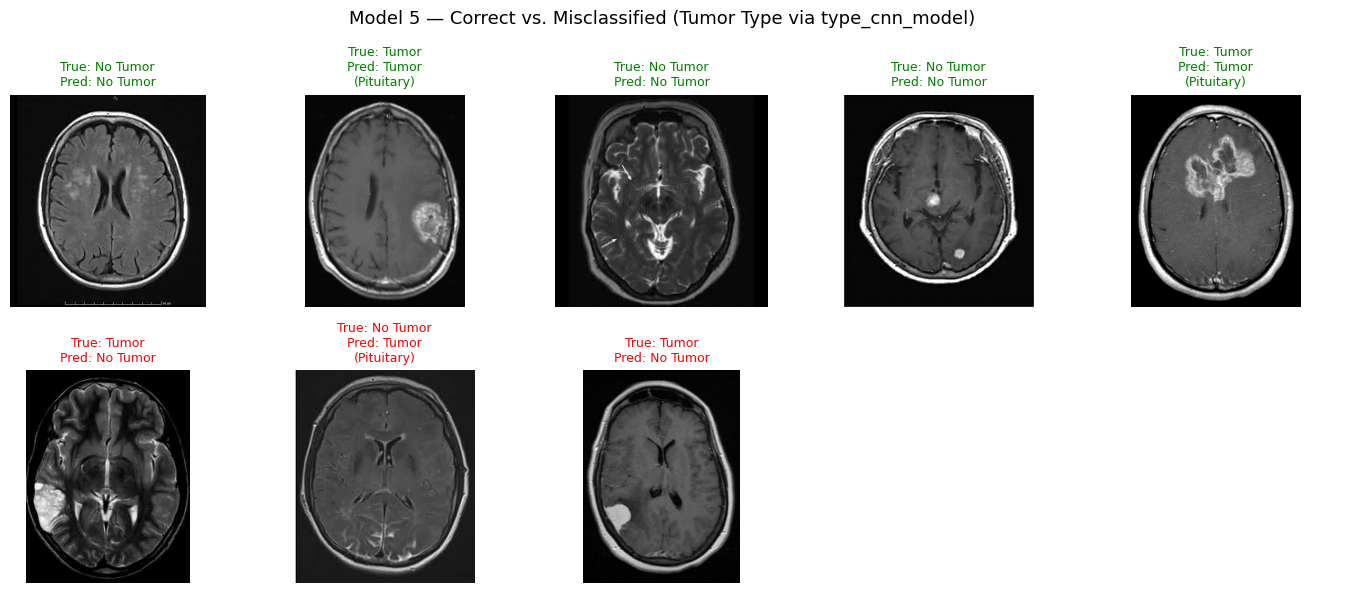

Correct: 48/51 (94.1%)
Wrong  : 3/51 (5.9%)


In [ ]:
cnn_preds_arr = np.array(cnn_preds)
cnn_true_arr  = np.array(cnn_true)
type_names    = ["Glioma", "Meningioma", "Pituitary"]

# For images Model 5 calls tumor, get the type from type_cnn_model (98% type accuracy)
type_preds_val = []
for p in val_paths:
    img = Image.open(p).convert("L").resize((64, 64))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = arr.reshape(1, 64, 64, 1)
    type_preds_val.append(np.argmax(type_cnn_model.predict(arr, verbose=0)))
type_preds_val = np.array(type_preds_val)

def make_title(true_yn, pred_yn, pred_type):
    true_str = "No Tumor" if true_yn == 0 else "Tumor"
    if pred_yn == 0:
        pred_str = "No Tumor"
    else:
        pred_str = f"Tumor\n({type_names[pred_type]})"
    return f"True: {true_str}\nPred: {pred_str}"

correct_idx = np.where(cnn_preds_arr == cnn_true_arr)[0]
wrong_idx   = np.where(cnn_preds_arr != cnn_true_arr)[0]

n_show  = min(5, len(correct_idx))
n_wrong = min(5, len(wrong_idx))
n_cols  = max(n_show, n_wrong)

fig, axes = plt.subplots(2, n_cols, figsize=(14, 6))
fig.suptitle("Model 5 — Correct vs. Misclassified (Tumor Type via type_cnn_model)", fontsize=13)

for col, idx in enumerate(correct_idx[:n_show]):
    img = Image.open(val_paths[idx]).convert("L")
    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(make_title(cnn_true_arr[idx], cnn_preds_arr[idx], type_preds_val[idx]),
                           fontsize=9, color="green")
    axes[0, col].axis("off")
for col in range(n_show, n_cols):
    axes[0, col].axis("off")

for col, idx in enumerate(wrong_idx[:n_wrong]):
    img = Image.open(val_paths[idx]).convert("L")
    axes[1, col].imshow(img, cmap="gray")
    axes[1, col].set_title(make_title(cnn_true_arr[idx], cnn_preds_arr[idx], type_preds_val[idx]),
                           fontsize=9, color="red")
    axes[1, col].axis("off")
for col in range(n_wrong, n_cols):
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Correct", fontsize=11)
axes[1, 0].set_ylabel("Misclassified", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Correct: {len(correct_idx)}/{len(val_paths)} ({len(correct_idx)/len(val_paths)*100:.1f}%)")
print(f"Wrong  : {len(wrong_idx)}/{len(val_paths)} ({len(wrong_idx)/len(val_paths)*100:.1f}%)")
